In [1]:
import torch
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
import pandas as pd
import numpy as np
import cv2


In [2]:
# Define a function to preprocess the images 
def process_image(image_path):
    
    image_path = image_path.replace("E:\\TARUN\\Projects\\Autism Detection\\Data\\data_png",'/kaggle/input/autism/')
    image_path = image_path.replace("\\",'/')
    
    # Read the original image
    original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Apply Canny edge detection
    edges = cv2.Canny(original_image, threshold1=30, threshold2=100)  # Adjust thresholds as needed

    # Find the contours of the edges
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Find the largest contour (the edges of the MRI structure)
    if len(contours) > 0:
        largest_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest_contour)

        # Crop the image based on the largest contour
        cropped_image = original_image[y:y+h, x:x+w]

    else:
        # If no contours are found, set cropped_image to the original image
        cropped_image = original_image

    # Resize to the desired image size (224x224)
    image_size = (224, 224)
    cropped_image = cv2.resize(cropped_image, image_size)

    # Convert single-channel image to RGB
    cropped_image = cv2.cvtColor(cropped_image, cv2.COLOR_GRAY2RGB)

    # Min-Max Normalization
    min_value = 0
    max_value = 255
    cropped_image = (cropped_image - min_value) / (max_value - min_value)

    return cropped_image


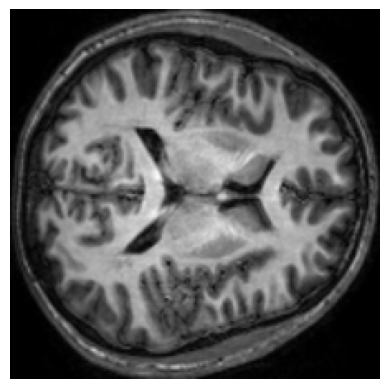

Image Type: <class 'numpy.ndarray'>
Image Shape: (224, 224, 3)


In [6]:
import matplotlib.pyplot as plt

sample = process_image('/kaggle/input/autism/32016.nii/32016_155.png')
def display_image(image):
    plt.imshow(image)
    plt.axis('off')
    plt.show()
    
    # Print image type and shape
    print(f"Image Type: {type(image)}")
    print(f"Image Shape: {image.shape}")
    
display_image(sample)

In [3]:
class CustomDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.process_image = process_image

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        img_path = self.data.iloc[index, 1]  # 'Image_paths' is the column containing file paths
        processed_image = self.process_image(img_path)
        label = int(self.data.iloc[index, 3])  # 'LABEL' is the column containing labels (0 or 1)
        
        # Convert to torch tensor
        image_tensor = torch.from_numpy(processed_image.transpose((2, 0, 1))).float()
        
        return image_tensor, label
    

In [4]:
# Define batch size
batch_size = 64

# Create train and test data loaders
train_dataset = CustomDataset('/kaggle/input/autism-csv/extracted_random_labels_train.csv')
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = CustomDataset('/kaggle/input/autism-csv/extracted_random_labels_test.csv')
test_loader = DataLoader(test_dataset, batch_size=batch_size)

val_dataset = CustomDataset('/kaggle/input/autism-csv/extracted_random_labels_validation.csv')
val_loader = DataLoader(val_dataset, batch_size=batch_size)


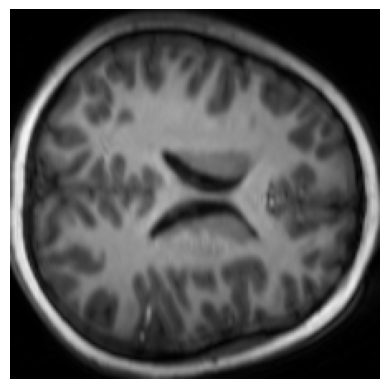

Image Type: <class 'numpy.ndarray'>
Image Shape: (224, 224, 3)
Image Type: <class 'torch.Tensor'>
Image Shape: torch.Size([3, 224, 224])


In [5]:
import matplotlib.pyplot as plt

# Access the first element of the tuple (image_tensor, label)
first_image, _ = test_dataset[0]

# Convert the PyTorch tensor to a NumPy array for displaying with matplotlib
first_image_numpy = first_image.numpy().transpose((1, 2, 0))

# Display the image
plt.imshow(first_image_numpy)
plt.axis('off')
plt.show()
# Print image type and shape
print(f"Image Type: {type(first_image_numpy)}")
print(f"Image Shape: {first_image_numpy.shape}")
print(f"Image Type: {type(first_image)}")
print(f"Image Shape: {first_image.shape}")


In [5]:
import torch

def patchify(image, patch_size):
    # Get the dimensions of the image
    _, height, width = image.size()

    # Calculate the number of patches in each dimension
    num_patches_h = height // patch_size
    num_patches_w = width // patch_size

    # Initialize an empty list to store the patches
    patches = []

    # Iterate over the image and extract patches
    for i in range(num_patches_h):
        for j in range(num_patches_w):
            # Calculate the starting and ending indices of the patch
            start_h = i * patch_size
            end_h = start_h + patch_size
            start_w = j * patch_size
            end_w = start_w + patch_size

            # Extract the patch from the image
            patch = image[:, start_h:end_h, start_w:end_w]

            # Append the patch to the list
            patches.append(patch)

    # Convert the list of patches into a PyTorch tensor
    patches = torch.stack(patches)

    return patches


In [10]:
# Create a sample image tensor
image = first_image

# Define the patch size
patch_size = 28

# Apply the patchify function
patches = patchify(image, patch_size)

# Print the shape of the patches tensor
print(f"Patches Type: {type(patches)}")
print(f"Patches Shape: {patches.shape}")

Patches Type: <class 'torch.Tensor'>
Patches Shape: torch.Size([64, 3, 28, 28])


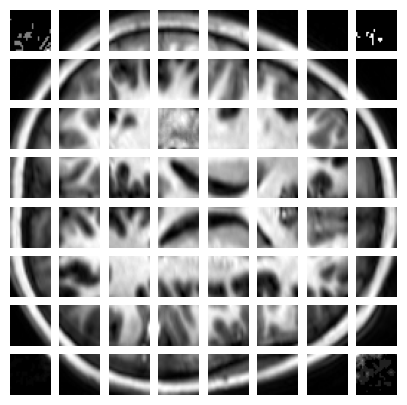

Patches Type: <class 'torch.Tensor'>
Patches Shape: torch.Size([64, 3, 28, 28])


In [14]:
import matplotlib.pyplot as plt
import torchvision

def display_patches(patches, num_rows, num_cols):
    # Reshape the patches tensor to (num_patches, channels, height, width)
    patches = patches.permute(0, 2, 3, 1)

    # Create a figure and axis
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5, 5))

    # Flatten the axis array if only one row or one column
    if num_rows == 1 and num_cols == 1:
        axes = [axes]

    # Iterate over patches and display them
    for i in range(min(num_rows * num_cols, patches.size(0))):
        row_idx = i // num_cols
        col_idx = i % num_cols
        patch = patches[i].numpy()  # Convert the patch to a NumPy array
        patch = (patch - patch.min()) / (patch.max() - patch.min())  # Normalize the patch values to [0, 1]
        axes[row_idx][col_idx].imshow(patch)
        axes[row_idx][col_idx].axis('off')

    plt.show()

# Assuming you have a variable 'patches' with shape [64, 3, 28, 28]
# You can adjust the number of rows and columns based on your preference
num_rows = 8
num_cols = 8

# Display the patches
display_patches(patches, num_rows, num_cols)
# Print the shape of the patches tensor
print(f"Patches Type: {type(patches)}")
print(f"Patches Shape: {patches.shape}")

In [6]:
import torch
import torch.nn as nn

class PatchEncoder(nn.Module):
    def __init__(self, image_size, patch_size, in_channels, embed_dim):
        super(PatchEncoder, self).__init__()
        self.image_size = image_size
        self.patch_size = patch_size
        self.in_channels = in_channels
        self.embed_dim = embed_dim
        self.num_patches = (image_size // patch_size) ** 2
        self.projection = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.projection(x)  # (batch_size, embed_dim, num_patches)
        x = x.flatten(2)  # (batch_size, embed_dim, num_patches)
        x = x.transpose(1, 2)  # (batch_size, num_patches, embed_dim)
        return x


In [7]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_hidden_dim, dropout=0.2):
        super(TransformerEncoderBlock, self).__init__()
        self.attention = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout)
        self.feedforward = nn.Sequential(
            nn.Linear(embed_dim, ff_hidden_dim),
            nn.ReLU(),
            nn.Linear(ff_hidden_dim, embed_dim),
        )
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        attention_output, _ = self.attention(x, x, x)
        x = x + self.dropout(attention_output)
        x = self.norm1(x)

        ff_output = self.feedforward(x)
        x = x + self.dropout(ff_output)
        x = self.norm2(x)

        return x


In [8]:
class VisionTransformer(nn.Module):
    def __init__(self, image_size, patch_size, in_channels, embed_dim, num_heads, num_layers, ff_hidden_dim, num_classes, dropout=0.2):
        super(VisionTransformer, self).__init__()
        
        self.patch_encoder = PatchEncoder(image_size, patch_size, in_channels, embed_dim)
        
        self.transformer_blocks = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, ff_hidden_dim, dropout) 
            for _ in range(num_layers)
        ])

        # MLP head
        self.mlp_head = nn.Sequential(
            nn.Linear(embed_dim, ff_hidden_dim),
            nn.GELU(),  # GELU activation function
            nn.Dropout(dropout),
            nn.Linear(ff_hidden_dim, embed_dim),
            nn.Dropout(dropout),
        )
        
        self.pooling = nn.AdaptiveAvgPool1d(1)  # Global average pooling
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.patch_encoder(x)
        
        for block in self.transformer_blocks:
            x = block(x)
        
        # MLP head
        x = self.mlp_head(x)

        x = self.pooling(x.transpose(1, 2)).squeeze(-1)
        x = self.fc(x)
        
        return x


In [9]:
# Define hyperparameters
image_size = 224
patch_size = 28
in_channels = 3  # Assuming RGB images
embed_dim = 768
num_heads = 12
num_layers = 12
ff_hidden_dim = 3072
num_classes = 1  # Binary classification


In [9]:
# Define hyperparameters
image_size = 224
patch_size = 28
in_channels = 3  # Assuming RGB images
embed_dim = 126
num_heads = 6
num_layers = 12
ff_hidden_dim = 512
num_classes = 1  # Binary classification


In [10]:
# Check if a GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [11]:
# Create the ViT model
vit_model = VisionTransformer(image_size, patch_size, in_channels, embed_dim, num_heads, num_layers, ff_hidden_dim, num_classes)
vit_model = vit_model.to(device)

# Print the model architecture
print(vit_model)

VisionTransformer(
  (patch_encoder): PatchEncoder(
    (projection): Conv2d(3, 768, kernel_size=(28, 28), stride=(28, 28))
  )
  (transformer_blocks): ModuleList(
    (0-11): 12 x TransformerEncoderBlock(
      (attention): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
      )
      (feedforward): Sequential(
        (0): Linear(in_features=768, out_features=3072, bias=True)
        (1): ReLU()
        (2): Linear(in_features=3072, out_features=768, bias=True)
      )
      (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.2, inplace=False)
    )
  )
  (mlp_head): Sequential(
    (0): Linear(in_features=768, out_features=3072, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=3072, out_features=768, bias=True)
    (4): Dropout(p=0.2, inplace=Fa

In [12]:
import torch.nn as nn

# Assuming you have a binary classification problem
num_classes = 1

# Use Binary Cross-Entropy Loss
criterion = nn.BCEWithLogitsLoss()
criterion = criterion.to(device)  # Move the criterion to the device (e.g., GPU) if applicable


In [13]:
import torch.optim as optim

# Define the hyperparameters
learning_rate = 0.001  # η
beta1 = 0.9  # β1
beta2 = 0.999  # β2
epsilon = 1e-7  # ε

# Create an instance of the Adam optimizer with the specified hyperparameters
optimizer = optim.Adam(vit_model.parameters(), lr=learning_rate, betas=(beta1, beta2), eps=epsilon)


In [14]:
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score

# Load your pretrained model weights here if needed
#model.load_state_dict(torch.load('NAdam_Skip_weights.pth'))

# Create empty lists to store training and validation losses and accuracies
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Set the current epoch number to continue from where you left off
current_epoch = 0  # Change this to the epoch you want to continue from

num_epochs = 75  # Set the total number of epochs you want to run

for epoch in range(current_epoch, num_epochs):
    vit_model.train()
    running_train_loss = 0.0
    train_preds = []
    train_targets = []

    # Training loop with a progress bar
    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs} (Training)'):
        images, labels = images.to(device), labels.to(device)  # Move data to GPU
        optimizer.zero_grad()
        outputs = vit_model(images)
        
        labels = labels.view(-1, 1)  # Reshape to match the shape of the model output
        # For binary classification, labels should be of type torch.float32
        labels = labels.float()

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

        # Apply a sigmoid activation and threshold for predictions
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        train_preds.extend(predicted.cpu().numpy())
        train_targets.extend(labels.cpu().numpy())

    # Calculate and print the average training loss for this epoch
    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Calculate training accuracy for this epoch
    train_accuracy = accuracy_score(train_targets, train_preds)
    train_accuracies.append(train_accuracy)

    vit_model.eval()  # Set the model to evaluation mode
    running_val_loss = 0.0
    val_preds = []
    val_targets = []

    # Validation loop with a progress bar
    for images, labels in tqdm(val_loader, desc=f'Epoch {epoch + 1}/{num_epochs} (Validation)'):
        images, labels = images.to(device), labels.to(device)  # Move data to GPU
        outputs = vit_model(images)
        
        labels = labels.view(-1, 1)  # Reshape to match the shape of the model output
        # For binary classification, labels should be of type torch.float32
        labels = labels.float()

        loss = criterion(outputs, labels)
        running_val_loss += loss.item()

        # Apply a sigmoid activation and threshold for predictions
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        val_preds.extend(predicted.cpu().numpy())
        val_targets.extend(labels.cpu().numpy())

    # Calculate and print the average validation loss for this epoch
    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    # Calculate validation accuracy for this epoch
    val_accuracy = accuracy_score(val_targets, val_preds)
    val_accuracies.append(val_accuracy)

    torch.save(vit_model.state_dict(), '/kaggle/working/vit_weights.pth')
    
    # Print loss and accuracy for this epoch
    print(f'Epoch [{epoch + 1}/{num_epochs}], Training Loss: {avg_train_loss:.4f}, Training Accuracy: {train_accuracy:.4f}')
    print(f'Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}')

print('Finished Training')


/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
Epoch 1/75 (Validation): 100%|██████████| 126/126 [01:43<00:00,  1.22it/s]


Epoch [1/75], Training Loss: 0.6936, Training Accuracy: 0.5097
Validation Loss: 0.6926, Validation Accuracy: 0.5187


Epoch 2/75 (Validation): 100%|██████████| 126/126 [00:52<00:00,  2.39it/s]


Epoch [2/75], Training Loss: 0.6930, Training Accuracy: 0.5123
Validation Loss: 0.6926, Validation Accuracy: 0.5187


Epoch 3/75 (Validation): 100%|██████████| 126/126 [00:51<00:00,  2.44it/s]


...

Epoch [73/75], Training Loss: 0.6928, Training Accuracy: 0.5128
Validation Loss: 0.6927, Validation Accuracy: 0.5187


Epoch 74/75 (Validation): 100%|██████████| 126/126 [00:47<00:00,  2.67it/s]


Epoch [74/75], Training Loss: 0.6929, Training Accuracy: 0.5128
Validation Loss: 0.6925, Validation Accuracy: 0.5187


Epoch 75/75 (Validation): 100%|██████████| 126/126 [00:48<00:00,  2.59it/s]

Epoch [75/75], Training Loss: 0.6928, Training Accuracy: 0.5124
Validation Loss: 0.6925, Validation Accuracy: 0.5187
Finished Training


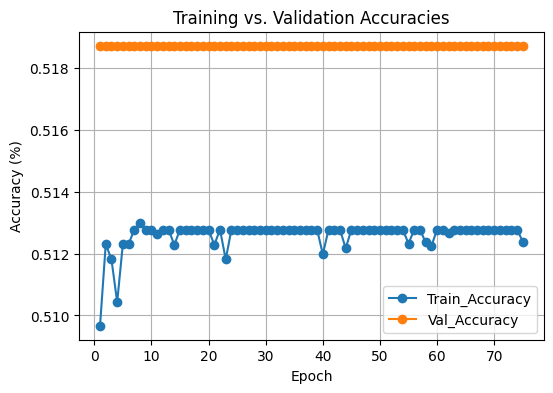

In [15]:
#Training vs Validation accuracies
import matplotlib.pyplot as plt

# Find the minimum number of epochs (between num_epochs and the number of epochs actually completed)
min_epochs = min(num_epochs, len(train_accuracies))

plt.figure(figsize=(6, 4))
plt.plot(range(1, min_epochs + 1), train_accuracies[:min_epochs], label='Train_Accuracy', marker='o')
plt.plot(range(1, min_epochs + 1), val_accuracies[:min_epochs], label='Val_Accuracy', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training vs. Validation Accuracies')
plt.legend()
plt.grid(True)
plt.show()

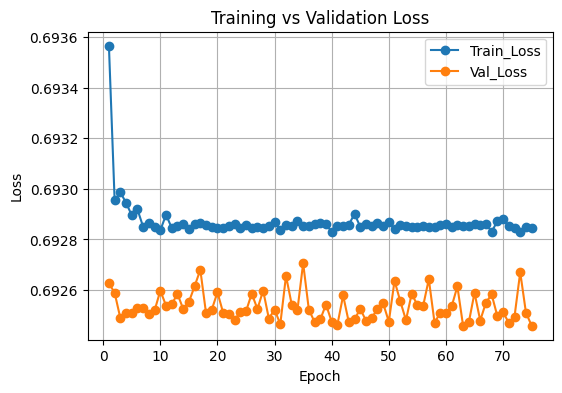

In [16]:
#Training vs Validation loss
import matplotlib.pyplot as plt

# Find the minimum number of epochs (between num_epochs and the number of epochs actually completed)
min_epochs = min(num_epochs, len(train_losses))

plt.figure(figsize=(6, 4))
plt.plot(range(1, min_epochs + 1), train_losses[:min_epochs], label='Train_Loss', marker='o')
plt.plot(range(1, min_epochs + 1), val_losses[:min_epochs], label='Val_Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.grid(True)
plt.show()

In [14]:
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score

# Load your pretrained model weights here if needed
#model.load_state_dict(torch.load('NAdam_Skip_weights.pth'))

# Create empty lists to store training and validation losses and accuracies
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Set the current epoch number to continue from where you left off
current_epoch = 0  # Change this to the epoch you want to continue from

num_epochs = 10  # Set the total number of epochs you want to run

for epoch in range(current_epoch, num_epochs):
    vit_model.train()
    running_train_loss = 0.0
    train_preds = []
    train_targets = []

    # Training loop with a progress bar
    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs} (Training)'):
        images, labels = images.to(device), labels.to(device)  # Move data to GPU
        optimizer.zero_grad()
        outputs = vit_model(images)
        
        labels = labels.view(-1, 1)  # Reshape to match the shape of the model output
        # For binary classification, labels should be of type torch.float32
        labels = labels.float()

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

        # Apply a sigmoid activation and threshold for predictions
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        train_preds.extend(predicted.cpu().numpy())
        train_targets.extend(labels.cpu().numpy())

    # Calculate and print the average training loss for this epoch
    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Calculate training accuracy for this epoch
    train_accuracy = accuracy_score(train_targets, train_preds)
    train_accuracies.append(train_accuracy)

    vit_model.eval()  # Set the model to evaluation mode
    running_val_loss = 0.0
    val_preds = []
    val_targets = []

    # Validation loop with a progress bar
    for images, labels in tqdm(val_loader, desc=f'Epoch {epoch + 1}/{num_epochs} (Validation)'):
        images, labels = images.to(device), labels.to(device)  # Move data to GPU
        outputs = vit_model(images)
        
        labels = labels.view(-1, 1)  # Reshape to match the shape of the model output
        # For binary classification, labels should be of type torch.float32
        labels = labels.float()

        loss = criterion(outputs, labels)
        running_val_loss += loss.item()

        # Apply a sigmoid activation and threshold for predictions
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        val_preds.extend(predicted.cpu().numpy())
        val_targets.extend(labels.cpu().numpy())

    # Calculate and print the average validation loss for this epoch
    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    # Calculate validation accuracy for this epoch
    val_accuracy = accuracy_score(val_targets, val_preds)
    val_accuracies.append(val_accuracy)

    torch.save(vit_model.state_dict(), '/kaggle/working/vit_weights.pth')
    
    # Print loss and accuracy for this epoch
    print(f'Epoch [{epoch + 1}/{num_epochs}], Training Loss: {avg_train_loss:.4f}, Training Accuracy: {train_accuracy:.4f}')
    print(f'Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}')

print('Finished Training')


/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
Epoch 1/10 (Validation): 100%|██████████| 126/126 [02:19<00:00,  1.11s/it]


Epoch [1/10], Training Loss: 0.7085, Training Accuracy: 0.5081
Validation Loss: 0.6928, Validation Accuracy: 0.5187


Epoch 2/10 (Validation): 100%|██████████| 126/126 [01:12<00:00,  1.75it/s]


Epoch [2/10], Training Loss: 0.6929, Training Accuracy: 0.5124
Validation Loss: 0.6928, Validation Accuracy: 0.5187


Epoch 3/10 (Validation): 100%|██████████| 126/126 [01:09<00:00,  1.81it/s]


...

Epoch [8/10], Training Loss: 0.6929, Training Accuracy: 0.5128
Validation Loss: 0.6927, Validation Accuracy: 0.5187


Epoch 9/10 (Validation): 100%|██████████| 126/126 [01:15<00:00,  1.67it/s]


Epoch [9/10], Training Loss: 0.6929, Training Accuracy: 0.5128
Validation Loss: 0.6926, Validation Accuracy: 0.5187


Epoch 10/10 (Validation): 100%|██████████| 126/126 [01:08<00:00,  1.85it/s]


Epoch [10/10], Training Loss: 0.6929, Training Accuracy: 0.5125
Validation Loss: 0.6925, Validation Accuracy: 0.5187
Finished Training


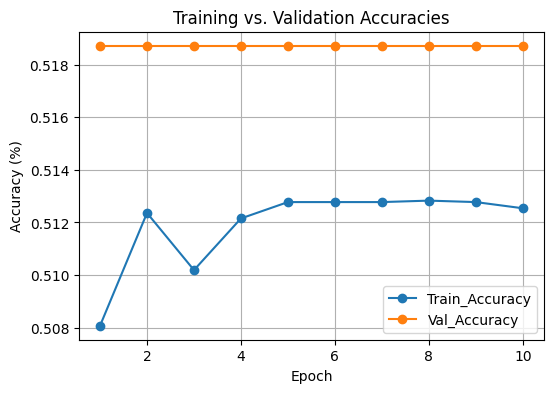

In [15]:
#Training vs Validation accuracies
import matplotlib.pyplot as plt

# Find the minimum number of epochs (between num_epochs and the number of epochs actually completed)
min_epochs = min(num_epochs, len(train_accuracies))

plt.figure(figsize=(6, 4))
plt.plot(range(1, min_epochs + 1), train_accuracies[:min_epochs], label='Train_Accuracy', marker='o')
plt.plot(range(1, min_epochs + 1), val_accuracies[:min_epochs], label='Val_Accuracy', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training vs. Validation Accuracies')
plt.legend()
plt.grid(True)
plt.show()

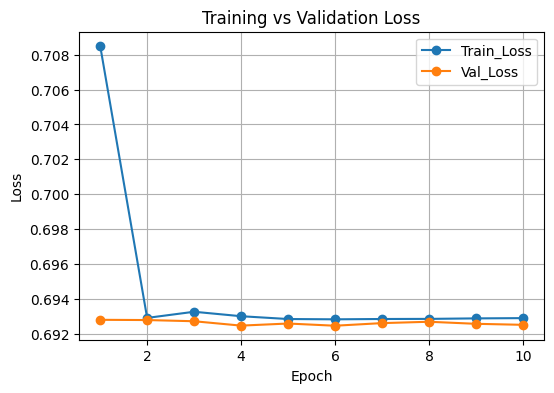

In [16]:
#Training vs Validation loss
import matplotlib.pyplot as plt

# Find the minimum number of epochs (between num_epochs and the number of epochs actually completed)
min_epochs = min(num_epochs, len(train_losses))

plt.figure(figsize=(6, 4))
plt.plot(range(1, min_epochs + 1), train_losses[:min_epochs], label='Train_Loss', marker='o')
plt.plot(range(1, min_epochs + 1), val_losses[:min_epochs], label='Val_Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, roc_auc_score, roc_curve, confusion_matrix, classification_report, f1_score, recall_score
import torch

# Initialize empty lists to store true labels and predicted class probabilities
true_labels = []
predicted_probs = []

# Set the model to evaluation mode
vit_model.eval()

# Move the model to the GPU
vit_model = vit_model.to(device)

with torch.no_grad():
    for images, labels in test_loader:
        # Move the data to the GPU
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)

        # Get the predicted class probabilities using softmax
        predicted_probs.extend(torch.softmax(outputs, dim=1)[:, 1].cpu().numpy())  # Probability of class 1

        # Store true labels
        true_labels.extend(labels.cpu().numpy())

# Calculate the accuracy
predicted_labels = [1 if prob >= 0.5 else 0 for prob in predicted_probs]
accuracy = accuracy_score(true_labels, predicted_labels)

# Calculate the AUC
roc_auc = roc_auc_score(true_labels, predicted_probs)

# Calculate precision, recall, and F1 score
precision = precision_score(true_labels, predicted_labels)
recall = recall_score(true_labels, predicted_labels)
f1 = f1_score(true_labels, predicted_labels)

# Calculate sensitivity (True Positive Rate)
conf_matrix = confusion_matrix(true_labels, predicted_labels)
sensitivity = conf_matrix[1, 1] / (conf_matrix[1, 1] + conf_matrix[1, 0])

# Calculate specificity (True Negative Rate)
specificity = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])

# Print the results
print(f'AUC: {roc_auc:.4f}')
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall (Sensitivity): {recall:.4f}')
print(f'Specificity: {specificity:.4f}')
print(f'F1 Score: {f1:.4f}')


In [ ]:
import matplotlib.pyplot as plt

# ROC Curve
fpr, tpr, thresholds = roc_curve(true_labels, predicted_probs)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Access values from the confusion matrix
TN = conf_matrix[0, 0]
FP = conf_matrix[0, 1]
FN = conf_matrix[1, 0]
TP = conf_matrix[1, 1]

# Now you can use these values as needed

# Define the confusion matrix
conf_matrix = np.array([[TN, FP], [FN, TP]])  

# Confusion Matrix
plt.figure(figsize=(6, 6))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)

# Annotate cells with their values
thresh = conf_matrix.max() / 2.0  # Set a threshold for text coloring
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, str(conf_matrix[i, j]), horizontalalignment="center",
                 color="white" if conf_matrix[i, j] > thresh else "black")

plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks([0, 1], ['Predicted 0', 'Predicted 1'])
plt.yticks([0, 1], ['Actual 0', 'Actual 1'])
plt.xlabel('True labels')
plt.ylabel('Predicted labels')
plt.show()